In [ ]:
# ============================================================
# Task 1: Term Deposit Subscription Prediction
# ============================================================

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,roc_curve,roc_auc_score

In [ ]:
# ============================================================
# 1. Load Dataset
# ============================================================

In [2]:
df = pd.read_csv("bank-full.csv", sep=";")

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


First 5 Rows:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  

Dataset Shape:
(45211, 17)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 45211 e

In [ ]:
# ============================================================
# 2. Exploratory Data Analysis
# ============================================================


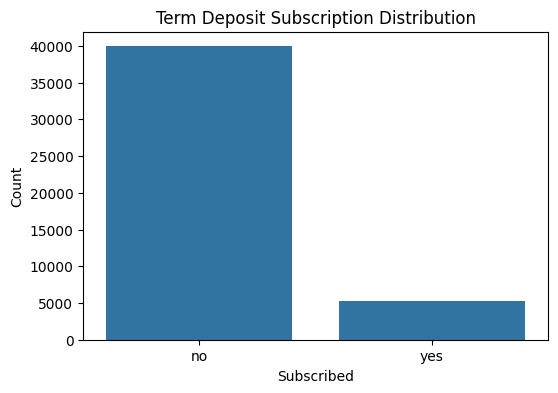

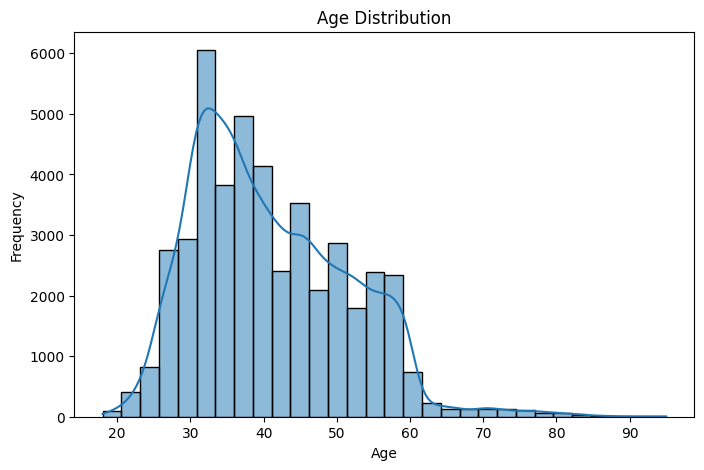

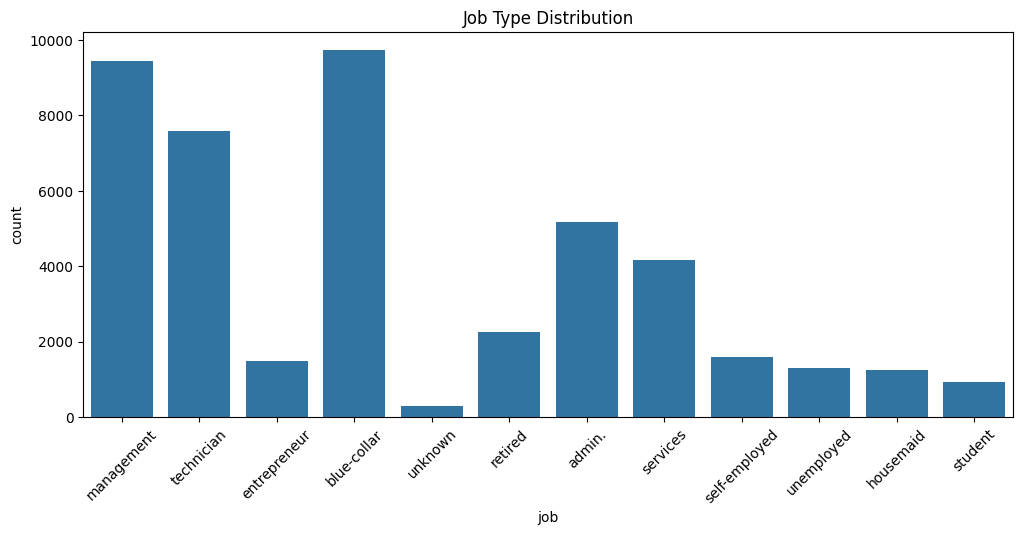

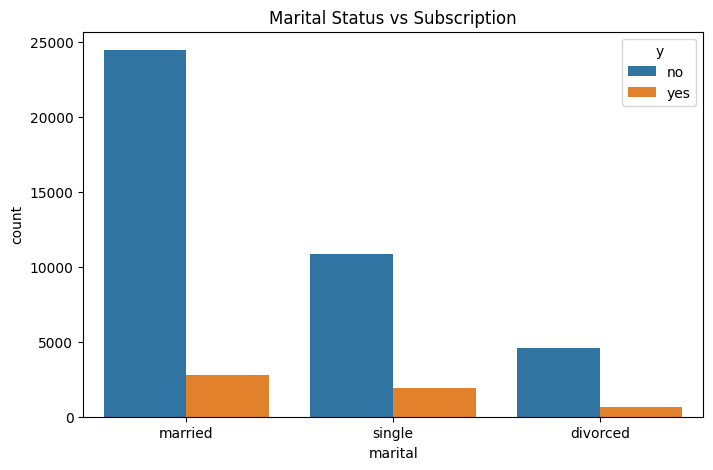

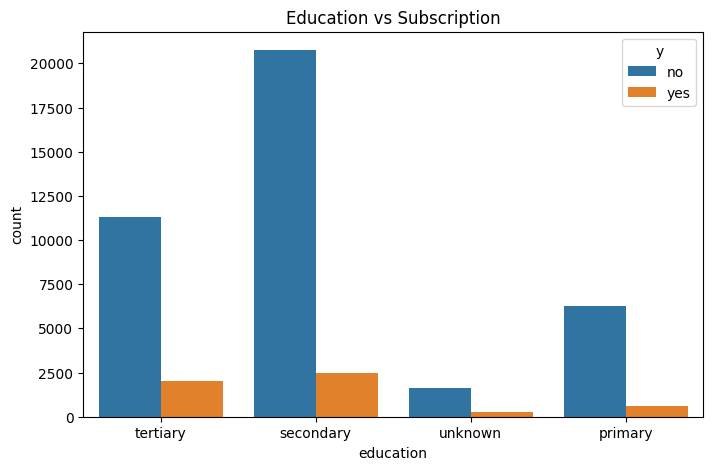

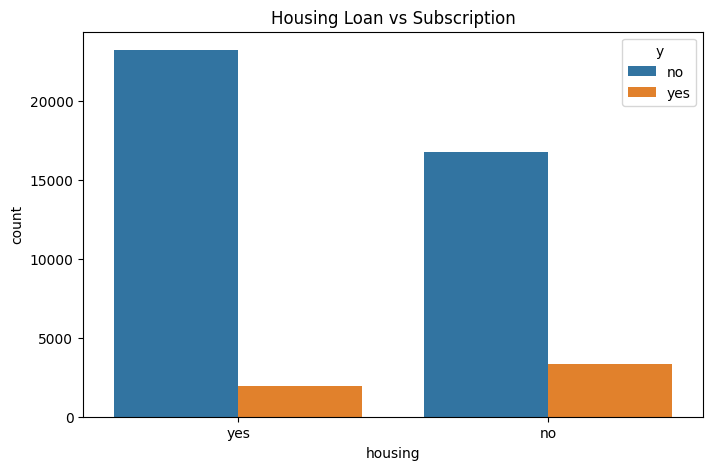

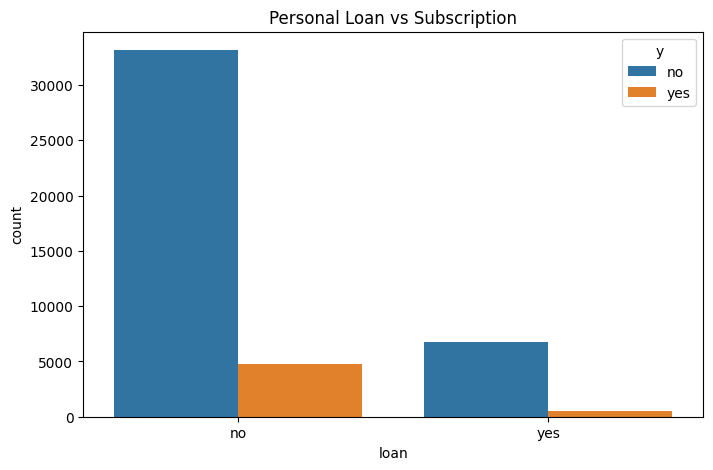

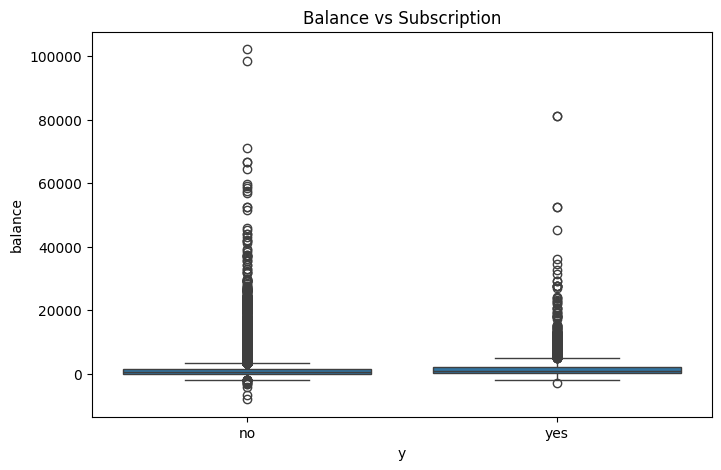

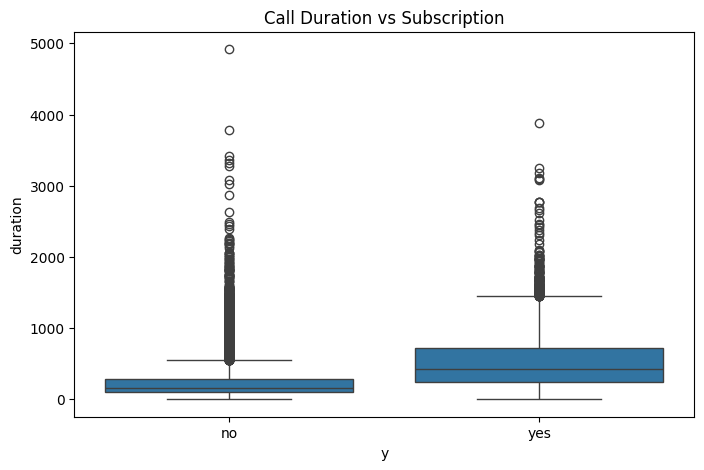

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x="y", data=df)
plt.title("Term Deposit Subscription Distribution")
plt.xlabel("Subscribed")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(12, 5))
sns.countplot(x="job", data=df)
plt.title("Job Type Distribution")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x="marital", hue="y", data=df)
plt.title("Marital Status vs Subscription")
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x="education", hue="y", data=df)
plt.title("Education vs Subscription")
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x="housing", hue="y", data=df)
plt.title("Housing Loan vs Subscription")
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x="loan", hue="y", data=df)
plt.title("Personal Loan vs Subscription")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x="y", y="balance", data=df)
plt.title("Balance vs Subscription")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x="y", y="duration", data=df)
plt.title("Call Duration vs Subscription")
plt.show()

In [ ]:
# ============================================================
# 3. Encode Categorical Features
# ============================================================

In [4]:
df_encoded = df.copy()

categorical_cols = df_encoded.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_cols)

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

print(df_encoded.head())
print(df_encoded.dtypes)

Categorical Columns:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='str')
   age  job  marital  education  default  balance  housing  loan  contact  \
0   58    4        1          2        0     2143        1     0        2   
1   44    9        2          1        0       29        1     0        2   
2   33    2        1          1        0        2        1     1        2   
3   47    1        1          3        0     1506        1     0        2   
4   33   11        2          3        0        1        0     0        2   

   day  month  duration  campaign  pdays  previous  poutcome  y  
0    5      8       261         1     -1         0         3  0  
1    5      8       151         1     -1         0         3  0  
2    5      8        76         1     -1         0         3  0  
3    5      8        92         1     -1         0         3  0  
4    5      8       198         1     -1         0    

In [ ]:
# ============================================================
# 4. Correlation Heatmap
# ============================================================

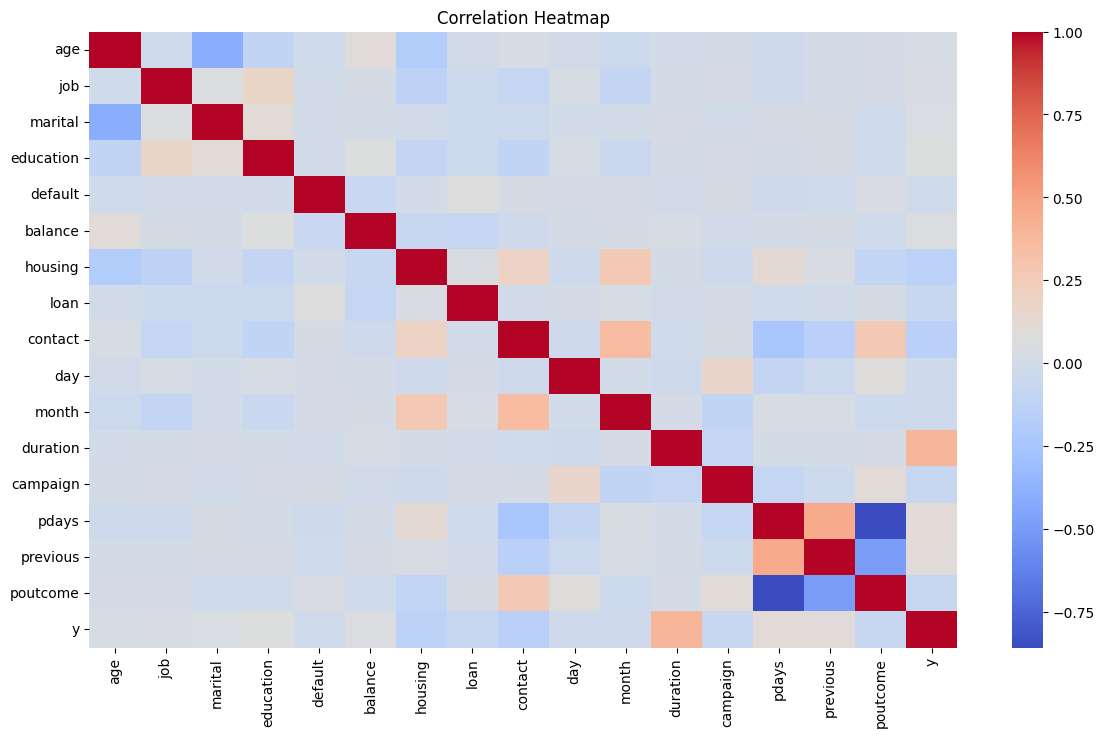

In [5]:
plt.figure(figsize=(14, 8))
sns.heatmap(df_encoded.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# ============================================================
# 5. Feature Selection
# ============================================================

In [6]:
X = df_encoded.drop("y", axis=1)
y = df_encoded["y"]

In [ ]:
# ============================================================
# 6. Train-Test Split
# ============================================================


In [7]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

In [ ]:
# ============================================================
# 7. Feature Scaling for Logistic Regression
# ============================================================

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# ============================================================
# 8. Logistic Regression Model
# ============================================================

In [9]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# ============================================================
# 9. Random Forest Model
# ============================================================

In [10]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
# ============================================================
# 10. Model Evaluation
# ============================================================

In [11]:
print("\n================ Logistic Regression Results ================")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("F1 Score:", f1_score(y_test, log_pred))
print("ROC AUC Score:", roc_auc_score(y_test, log_prob))


print("\n================ Random Forest Results ================")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC AUC Score:", roc_auc_score(y_test, rf_prob))


================ Logistic Regression Results ================
Accuracy: 0.8914077186774301
F1 Score: 0.3273972602739726
ROC AUC Score: 0.8725826898970541

================ Random Forest Results ================
Accuracy: 0.9025765785690589
F1 Score: 0.45245494095711625
ROC AUC Score: 0.926150047406941


In [ ]:
# ============================================================
# 11. Random Forest Confusion Matrix
# ============================================================

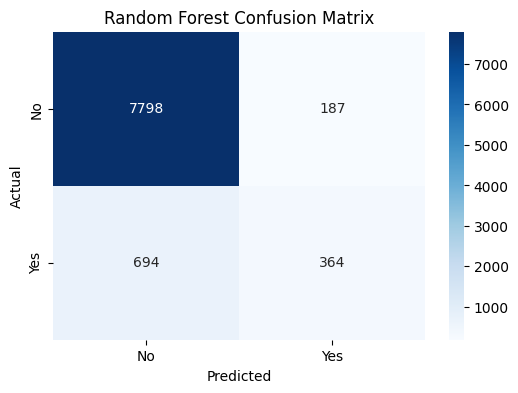

In [12]:
plt.figure(figsize=(6, 4))
cm_rf = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# ============================================================
# Logistic Regression Confusion Matrix
# ============================================================

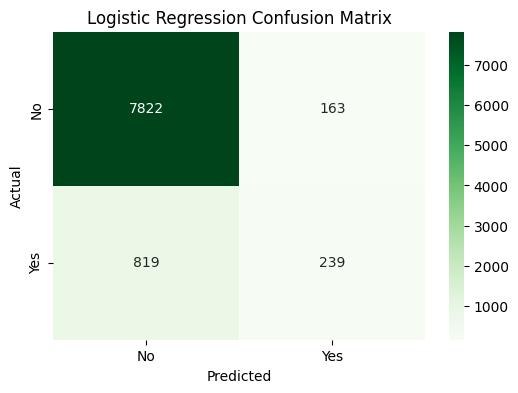

In [13]:
cm_lr = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No','Yes'],
    yticklabels=['No','Yes']
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# ============================================================
# Comparing Both Confusion Matrix
# ============================================================

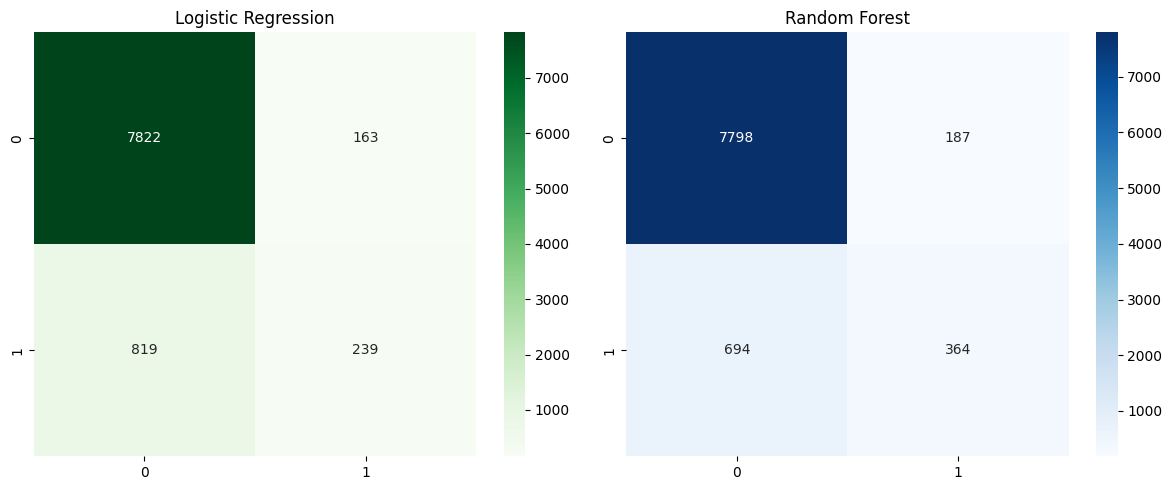

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title("Logistic Regression")

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 12. ROC Curve
# ============================================================

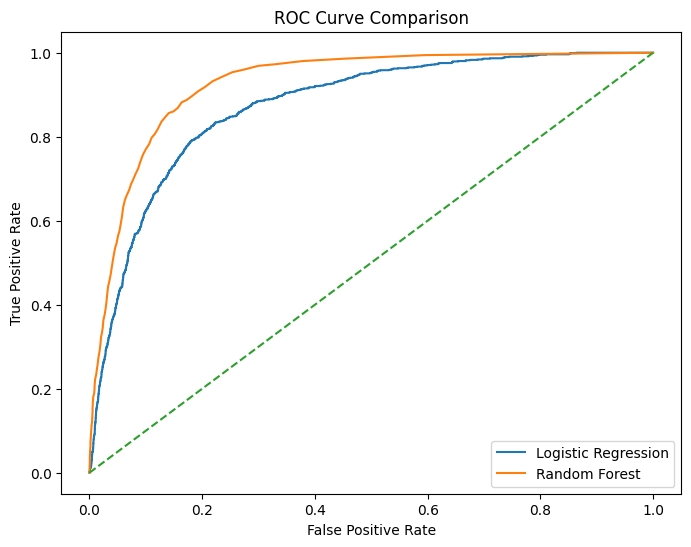

In [15]:
log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))
plt.plot(log_fpr, log_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
# ============================================================
# 13. Feature Importance - Random Forest
# ============================================================


Feature Importance:
      Feature  Importance
11   duration    0.379152
5     balance    0.084972
10      month    0.082665
0         age    0.080456
9         day    0.071877
8     contact    0.045422
13      pdays    0.043220
1         job    0.036739
15   poutcome    0.035921
6     housing    0.035409
12   campaign    0.032722
14   previous    0.021669
3   education    0.020629
2     marital    0.017291
7        loan    0.010435
4     default    0.001421


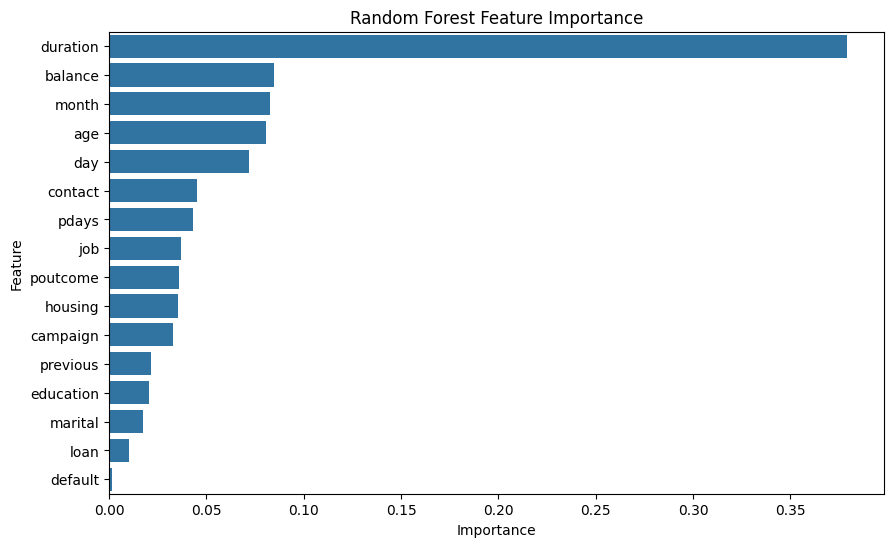

In [16]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Random Forest Feature Importance")
plt.show()

In [ ]:
# ============================================================
# 14. SHAP Explainability - Fixed Version
# ============================================================

SHAP values shape: (100, 16, 2)
X_test_sample shape: (100, 16)


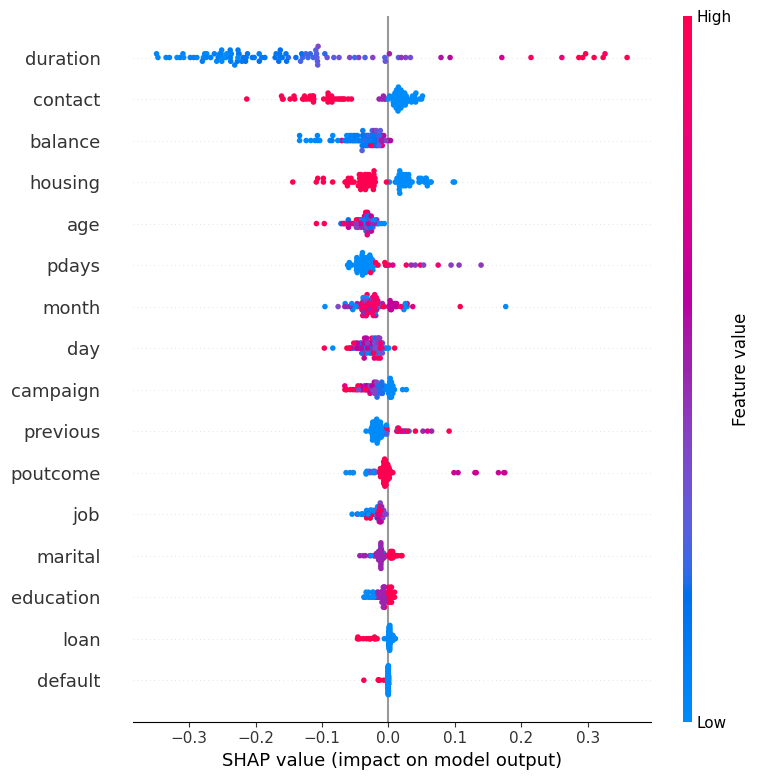


Explanation for Prediction 1
Actual Value: 0
Predicted Value: 0
Subscription Probability: 0.18


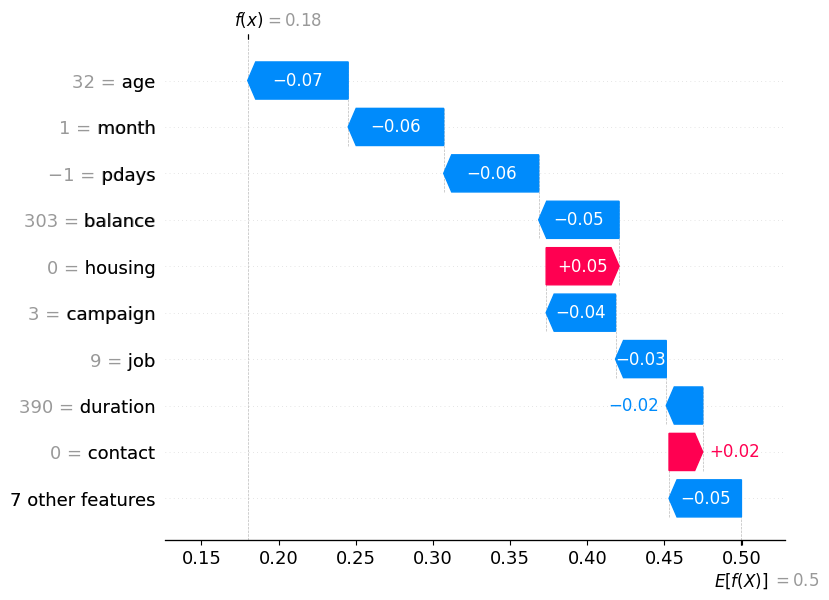


Explanation for Prediction 2
Actual Value: 0
Predicted Value: 0
Subscription Probability: 0.01


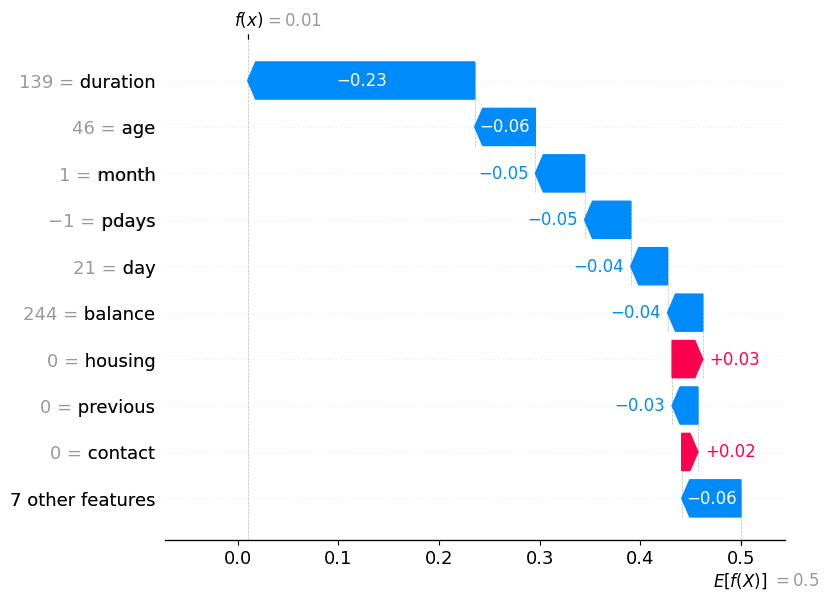


Explanation for Prediction 3
Actual Value: 1
Predicted Value: 1
Subscription Probability: 0.57


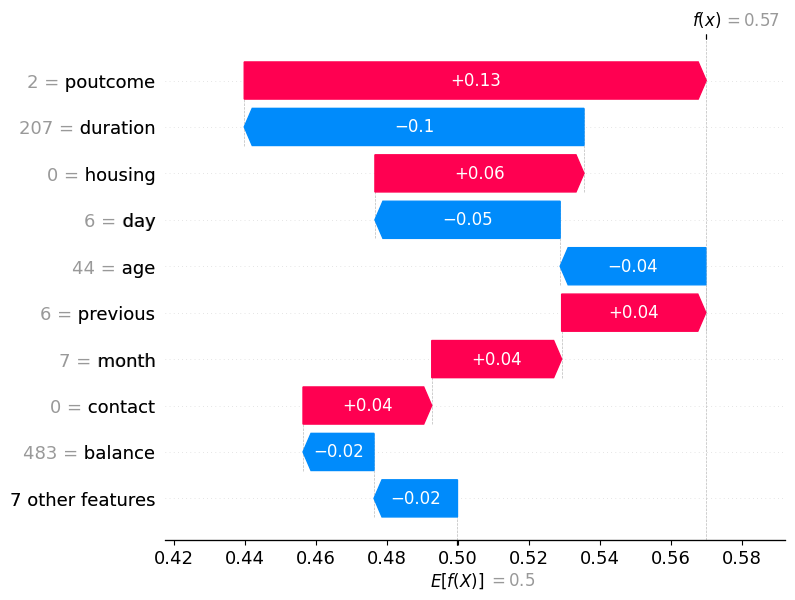


Explanation for Prediction 4
Actual Value: 0
Predicted Value: 0
Subscription Probability: 0.0


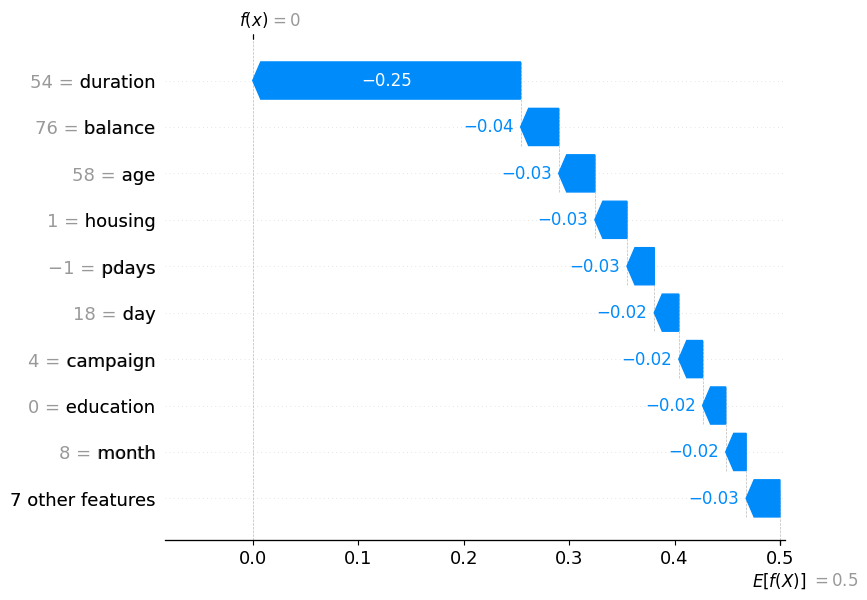


Explanation for Prediction 5
Actual Value: 0
Predicted Value: 0
Subscription Probability: 0.0


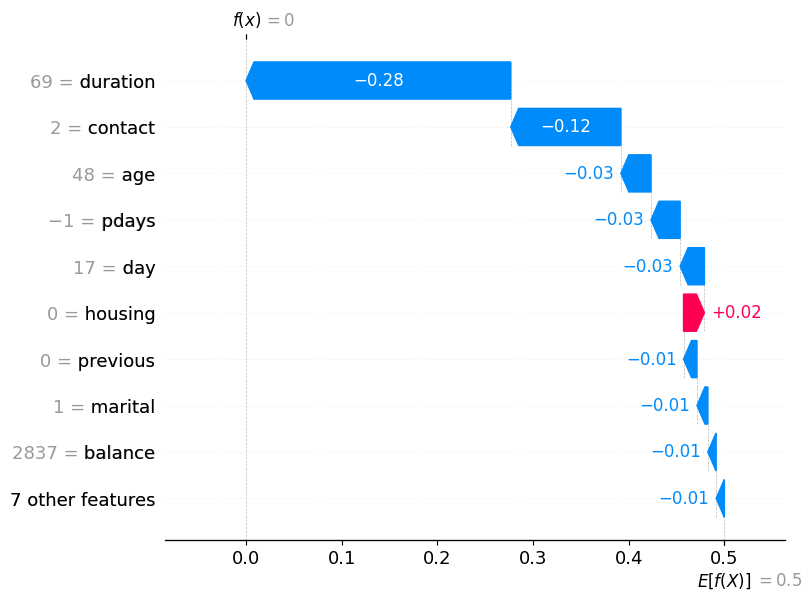

In [25]:
X_test_sample = X_test.sample(100, random_state=42)

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer(X_test_sample)

print("SHAP values shape:", shap_values.values.shape)
print("X_test_sample shape:", X_test_sample.shape)

# SHAP Summary Plot for class 1 = subscribed yes
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_sample,
    show=True
)

# Explain at least 5 predictions using waterfall plots
for i in range(5):
    print(f"\nExplanation for Prediction {i + 1}")
    print("Actual Value:", y_test.loc[X_test_sample.index[i]])
    print("Predicted Value:", rf_model.predict(X_test_sample.iloc[[i]])[0])
    print("Subscription Probability:", rf_model.predict_proba(X_test_sample.iloc[[i]])[0][1])

    shap.plots.waterfall(
        shap_values[i, :, 1],
        show=True
    )

In [ ]:
## Conclusion

# This project successfully developed machine learning models to predict whether a customer will subscribe to a term deposit. 
# Logistic Regression and Random Forest were trained and evaluated using performance metrics such as Accuracy, F1-Score, and ROC-AUC. 
# Among the two models, Random Forest achieved the best performance.
# Additionally, SHAP was used to explain model predictions and identify the most influential factors affecting customer subscription decisions. 
# The results demonstrate how machine learning can help banks improve marketing strategies and target potential customers more effectively.

